# Évaluation rapide de checkpoints (MSE / CSI)
Entrées manuelles : chemins des données, liste de PKL (test), dossier de checkpoints, liste d’epochs.
Calculs : MSE (h, u, v) et CSI (pas de CSI_over) aux horizons 30 min / 3 h / 6 h / 12 h (1 / 6 / 12 / 24 pas).
Charge les poids via `modulus.launch.utils.load_checkpoint` en réutilisant les stats présentes dans le dossier de checkpoints.

In [1]:
import os, json, math
import torch, dgl
import numpy as np
import matplotlib.pyplot as plt
from typing import List
import sys

# Ajouter le repo au PYTHONPATH
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.append(ROOT)

from python.create_dgl_dataset import TelemacDataset
from python.CustomMeshGraphNet import MeshGraphNet
from modulus.launch.utils import load_checkpoint

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [111]:
# =====================
# Paramètres utilisateur (à adapter)
# =====================

# Graphe de base (DGL) et PKL de test
DATA_DIR = "/work/m24046/m24046mrcr/paper/Experience2/Multimesh_8_32.bin"
DYNAMIC_DIR = [ 
    "/work/m24046/m24046mrcr/results_data_30min_35_70_maillagex8/Group_1_peak_2600_Group_1_peak_2600_0_0-80_interpolated.pkl",
]

# Dossier checkpoints (contient node_stats.json / edge_stats.json + checkpoint.*.pt)
CKPT_DIR = "/work/m24046/m24046mrcr/paper/Experience2/Seed0/"
CHECKPOINT_EPOCHS = [0, 50,100,150,200,250,300,350,400,450,500,550,600]  # epochs à évaluer (ex: 0, 40, 80, ...)

# Paramètres modèle (cohérents avec l'entraînement)
NUM_INPUT_FEATURES = 9
NUM_EDGE_FEATURES = 3
NUM_OUTPUT_FEATURES = 3
MP_LAYERS = 10
DO_CONCAT_TRICK = True
NUM_PROCESSOR_CHECKPOINT_SEGMENTS = 0

# Horizons (en pas de 30 min)
HORIZONS_STEPS = [1]#, 6, 12, 24]   # 30 min, 3h, 6h, 12h

# Nombre de séquences à évaluer (prend les premières)
MAX_SEQUENCES = 205

# Seuil CSI
THRESHOLD_M = 0.05

In [112]:
import pickle as pkl
with open(DYNAMIC_DIR[0], 'rb') as f:
    data = pkl.load(f)
print(len(data))

31


In [101]:
# =====================
# Fonctions utilitaires
# =====================
def build_model():
    return MeshGraphNet(
        NUM_INPUT_FEATURES,
        NUM_EDGE_FEATURES,
        NUM_OUTPUT_FEATURES,
        processor_size=MP_LAYERS,
        hidden_dim_processor=64,
        hidden_dim_node_encoder=64,
        hidden_dim_edge_encoder=64,
        hidden_dim_node_decoder=64,
        do_concat_trick=DO_CONCAT_TRICK,
        num_processor_checkpoint_segments=NUM_PROCESSOR_CHECKPOINT_SEGMENTS,
    )

def load_model_checkpoint(model, ckpt_dir, epoch):
    # charge le checkpoint demandé (dernier si epoch=None)
    load_checkpoint(ckpt_dir, models=model, device=device, epoch=epoch)
    model.to(device)
    model.eval()
    return model

def build_dataset(sequence_length, overlap=1, split="test"):
    ds = TelemacDataset(
        name=f"eval_{split}",
        data_dir=DATA_DIR,
        dynamic_data_files=DYNAMIC_DIR,
        split=split,
        ckpt_path=CKPT_DIR,
        normalize=True,
        sequence_length=sequence_length,
        overlap=overlap,
    )
    return ds

def _denorm(xn, mean, std):
    return xn * std + mean

def _renorm(x, mean, std):
    return (x - mean) / (std + 1e-12)

def csi_from_binary(pred_mask, gt_mask):
    tp = np.logical_and(pred_mask, gt_mask).sum()
    fp = np.logical_and(pred_mask, ~gt_mask).sum()
    fn = np.logical_and(~pred_mask, gt_mask).sum()
    denom = tp + fp + fn
    return float(tp / denom) if denom > 0 else math.nan

def evaluate_model(model, ds, horizons_steps, max_sequences=10, threshold=0.05):
    stats = ds.node_stats
    dyn_start = ds.base_graph.ndata['static'].shape[1]
    mx = torch.tensor([stats['h'].item(), stats['u'].item(), stats['v'].item()], device=device)
    sx = torch.tensor([stats['h_std'].item(), stats['u_std'].item(), stats['v_std'].item()], device=device)
    dy_mean = torch.tensor([stats['delta_h'].item(), stats['delta_u'].item(), stats['delta_v'].item()], device=device)
    dy_std  = torch.tensor([stats['delta_h_std'].item(), stats['delta_u_std'].item(), stats['delta_v_std'].item()], device=device)

    agg = {h: {"mse": [], "csi": []} for h in horizons_steps}
    nseq = min(max_sequences, len(ds))
    max_h = max(horizons_steps)
    print(len(ds))
    for idx in range(nseq):
        graphs = ds[idx]
        if len(graphs) <= max_h:
            continue
        g = graphs[0].to(device)
        static_part = g.ndata['x'][:, :dyn_start]
        xn_t = g.ndata['x'][:, dyn_start:dyn_start+3]

        # masques BC
        onehot = static_part[:, :4]
        q_mask = (onehot == torch.tensor([0,0,1,0], device=device)).all(dim=1)
        h_mask = (onehot == torch.tensor([0,1,0,0], device=device)).all(dim=1)

        for t in range(max_h):
            with torch.no_grad():
                y_pred_n = model(g.ndata['x'], g.edata['x'], g)
            x_t = _denorm(xn_t, mx, sx)
            y_pred = _denorm(y_pred_n, dy_mean, dy_std)
            x_t1 = x_t + y_pred

            # GT @ t+1
            x_gt_n = graphs[t+1].ndata['x'][:, dyn_start:dyn_start+3].to(device)
            x_gt = _denorm(x_gt_n, mx, sx)

            # CL
            x_t1[q_mask] = x_gt[q_mask]
            x_t1[h_mask, 0:1] = x_gt[h_mask, 0:1]

            step = t+1
            if step in horizons_steps:
                mse = torch.mean((x_t1 - x_gt)**2, dim=0).detach().cpu().numpy()  # [3]
                h_pred = x_t1[:,0].detach().cpu().numpy()
                h_gt = x_gt[:,0].detach().cpu().numpy()
                csi = csi_from_binary(h_pred >= threshold, h_gt >= threshold)
                agg[step]["mse"].append(mse)
                agg[step]["csi"].append(csi)

            # réinjection
            xn_t = _renorm(x_t1, mx, sx)
            g = g.clone()
            g.ndata['x'] = torch.cat([static_part, xn_t], dim=1)

    summary = {}
    for h in horizons_steps:
        if len(agg[h]["mse"]) == 0:
            continue
        summary[h] = {
            "mse_mean": np.nanmean(np.stack(agg[h]["mse"], axis=0), axis=0).tolist(),
            "csi_mean": float(np.nanmean(agg[h]["csi"])),
        }
    return summary

def evaluate_checkpoints(epochs: List[int], horizons_steps=[1,6,12,24], max_sequences=10):
    ds = build_dataset(sequence_length=max(horizons_steps)+1, overlap=1, split="test")
    metrics_per_epoch = {}
    for ep in epochs:
        model = build_model()
        load_model_checkpoint(model, CKPT_DIR, epoch=ep)
        summary = evaluate_model(model, ds, horizons_steps, max_sequences=max_sequences, threshold=THRESHOLD_M)
        metrics_per_epoch[ep] = summary
    return metrics_per_epoch

def plot_curves(metrics, horizons_steps):
    if not metrics:
        print("Pas de résultats")
        return
    epochs = sorted(metrics.keys())
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    for h in horizons_steps:
        csi_vals = [metrics[e].get(h, {}).get('csi_mean', np.nan) for e in epochs]
        axes[0].plot(epochs, csi_vals, marker='o', label=f"h={h}")
        mse_h = [metrics[e].get(h, {}).get('mse_mean', [np.nan])[0] for e in epochs]
        axes[1].plot(epochs, mse_h, marker='o', label=f"h={h}")
    axes[0].set_title("CSI(h) vs epoch")
    axes[1].set_title("MSE(h) vs epoch")
    
    axes[1].set_yscale('log')

    for ax in axes:
        ax.set_xlabel("epoch")
        ax.grid(True, alpha=0.3)
        ax.legend()
    plt.tight_layout(); plt.show()

In [102]:
# =====================
# Lancement de l'éval
# =====================
metrics = evaluate_checkpoints(CHECKPOINT_EPOCHS, horizons_steps=HORIZONS_STEPS, max_sequences=MAX_SEQUENCES)
metrics

[16:35:49 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience2/Seed0/MeshGraphNet.0.0.mdlus to device cuda
[16:35:49 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience2/Seed0/checkpoint.0.0.pt to device cuda


Loading normalization statistics...
30


[16:35:50 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience2/Seed0/MeshGraphNet.0.50.mdlus to device cuda
[16:35:50 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience2/Seed0/checkpoint.0.50.pt to device cuda


30


[16:35:51 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience2/Seed0/MeshGraphNet.0.100.mdlus to device cuda
[16:35:51 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience2/Seed0/checkpoint.0.100.pt to device cuda


...

[16:35:56 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience2/Seed0/MeshGraphNet.0.550.mdlus to device cuda
[16:35:56 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience2/Seed0/checkpoint.0.550.pt to device cuda


30


[16:35:57 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience2/Seed0/MeshGraphNet.0.600.mdlus to device cuda
[16:35:57 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience2/Seed0/checkpoint.0.600.pt to device cuda


30


{0: {1: {'mse_mean': [0.0035786665976047516,
    0.001119909225963056,
    0.0006766427541151643],
   'csi_mean': 0.9565398102654885}},
 50: {1: {'mse_mean': [0.001113736187107861,
    0.0005920442054048181,
    0.00038298952858895063],
   'csi_mean': 0.9676563485270755}},
 100: {1: {'mse_mean': [0.0008585306932218373,
    0.0004947570851072669,
    0.0002909916511271149],
   'csi_mean': 0.970805837814881}},
 150: {1: {'mse_mean': [0.0010684060398489237,
    0.0005168160423636436,
    0.0002981161524076015],
   'csi_mean': 0.9742304504148925}},
 200: {1: {'mse_mean': [0.0009481252636760473,
    0.0005298125906847417,
    0.00027585349744185805],
   'csi_mean': 0.9757623826329621}},
 250: {1: {'mse_mean': [0.0008675680728629231,
    0.000471124512841925,
    0.00024347439466509968],
   'csi_mean': 0.9758603685650884}},
 300: {1: {'mse_mean': [0.0010679803090170026,
    0.0005433352780528367,
    0.00029445698601193726],
   'csi_mean': 0.9744397117274883}},
 350: {1: {'mse_mean': [0.0009

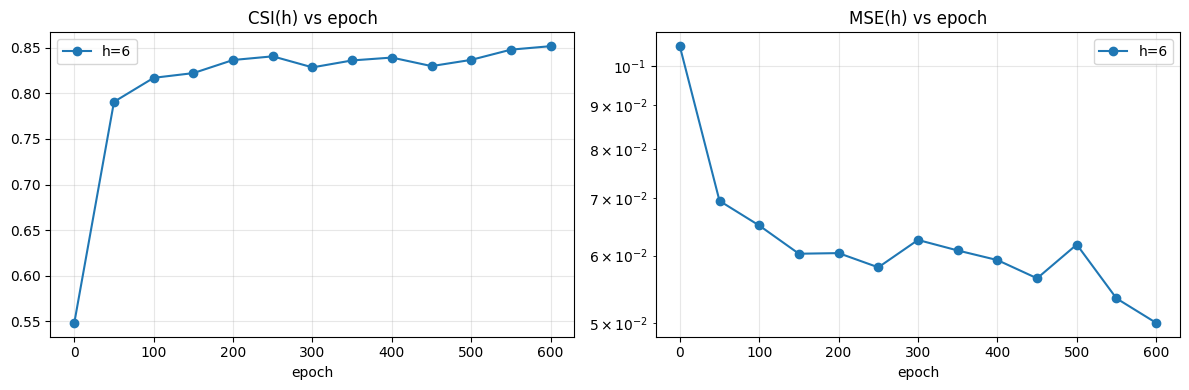

In [88]:
plot_curves(metrics, HORIZONS_STEPS)

In [89]:
import pandas as pd

rows = []
for ep, res in metrics.items():
    for h, vals in res.items():
        mse_mean = vals.get("mse_mean", [np.nan, np.nan, np.nan])
        rows.append({
            "epoch": ep,
            "horizon_steps": h,
            "mse_h": mse_mean[0],
            "mse_u": mse_mean[1],
            "mse_v": mse_mean[2],
            "csi": vals.get("csi_mean", np.nan),
        })

df = pd.DataFrame(rows)
csv_path = "metrics_export.csv"  # adapte le chemin si besoin
df.to_csv(csv_path, index=False)
df

,epoch,horizon_steps,mse_h,mse_u,mse_v,csi
0,0,6,0.105554,0.023124,0.007606,0.548015
1,50,6,0.069545,0.017424,0.005722,0.790816
2,100,6,0.065077,0.016517,0.005091,0.817197
3,150,6,0.060305,0.015055,0.005094,0.822385
4,200,6,0.060404,0.015237,0.004994,0.836775
5,250,6,0.058130,0.014926,0.004708,0.840798
6,300,6,0.062586,0.015217,0.005472,0.828676
7,350,6,0.060837,0.015287,0.005129,0.836302
8,400,6,0.059280,0.014927,0.005169,0.839449
9,450,6,0.056433,0.014299,0.005000,0.830076
